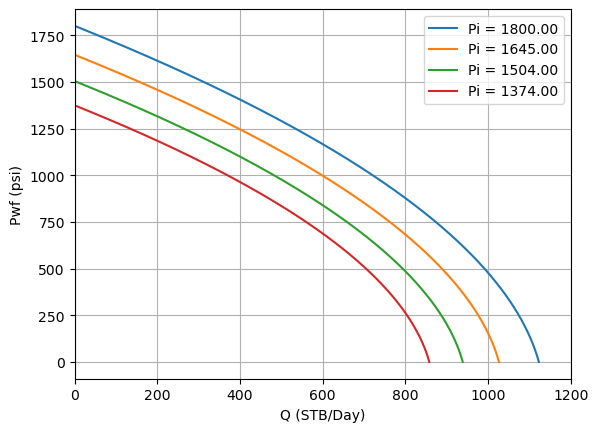

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
Res_pressures = [1800, 1645, 1504, 1374]
##Using Excel:
Pbp = 3281
J = 1.12
for i in Res_pressures:
    if i >= Pbp:  
        q = J*(i - Pbp)
        qmax = q / (1 - 0.2*(Pbp/i) - 0.8*(Pbp/i)**2)
    else:
        # For Pr < Pb, use small deltaP to estimate qmax
        deltaP = 10
        Pstart = i - deltaP
        q = J * deltaP
        qmax = q / (1 - 0.2*(Pstart/i) - 0.8*(Pstart/i)**2)
    q = []
    pressure = np.linspace (0, i, 5000)
    pressure_drop = 50
    for j in pressure:
        if j >= Pbp:
            q.append(J*(i - j))
        else:
            q.append(qmax*(1-0.2*(j/i) - 0.8*(j/i)**2))
    plt.plot(q, pressure, label= f"Pi = {i:.2f}")
plt.grid(True)
plt.xlabel("Q (STB/Day)")
plt.xlim(0, 1200)
plt.ylabel("Pwf (psi)")
plt.legend()
